# GA 알고리즘 검증

## 환경 설정

In [ ]:
BASE_DATA_PATH = 'data/small_data'

## 모듈 import

In [2]:
from utils import DataLoader
from algorithms.genetic.encoder import encode
from algorithms.genetic.operators import random_chromosome

## 데이터 로드

In [3]:
data = DataLoader(BASE_DATA_PATH).load_all_data()

print(f"Jobs: {len(data['jobs'])}개")
print(f"Machines: {len(data['machines'])}개")
print(f"Operations: {len(data['operations'])}개")

Jobs: 10개
Machines: 8개
Operations: 35개


## 1. encode() 검증

In [4]:
encoded = encode(data)

print("job_index_table:", encoded.job_index_table)
print("machine_index_table:", encoded.machine_index_table)
print("pm_levels:", encoded.pm_levels)
print()
print(f"operation_index_table 길이: {len(encoded.operation_index_table)}")
print(f"  처음 5개: {encoded.operation_index_table[:5]}")
print(f"  마지막 5개: {encoded.operation_index_table[-5:]}")
print()
print("feasible_machine_table 처음 5개:")
for i in range(5):
    op = encoded.operation_index_table[i]
    print(f"  {op}: {encoded.feasible_machine_table[i]}")

job_index_table: ['J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'J8', 'J9', 'J10']
machine_index_table: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8']
pm_levels: [0.05, 0.1, 0.2, 0.5, 1.0]

operation_index_table 길이: 35
  처음 5개: ['J1_O1', 'J1_O2', 'J1_O3', 'J1_O4', 'J2_O1']
  마지막 5개: ['J9_O3', 'J9_O4', 'J10_O1', 'J10_O2', 'J10_O3']

feasible_machine_table 처음 5개:
  J1_O1: ['M1', 'M2', 'M3']
  J1_O2: ['M4', 'M5']
  J1_O3: ['M1', 'M2', 'M3']
  J1_O4: ['M6', 'M7', 'M8']
  J2_O1: ['M1', 'M2', 'M3']


In [5]:
# 자동 검증
assert len(encoded.job_index_table) == len(data['jobs']), "job_index_table 길이 오류"
assert len(encoded.machine_index_table) == len(data['machines']), "machine_index_table 길이 오류"
assert len(encoded.operation_index_table) == len(data['operations']), "operation_index_table 길이 오류"
assert len(encoded.feasible_machine_table) == len(encoded.operation_index_table), "feasible_machine_table 길이 오류"

# 각 op의 feasible 머신이 모두 machine_index_table 안에 존재하는지
machine_set = set(encoded.machine_index_table)
for op, feasible in zip(encoded.operation_index_table, encoded.feasible_machine_table):
    assert len(feasible) > 0, f"{op}의 feasible 머신이 비어있음"
    assert all(m in machine_set for m in feasible), f"{op}의 feasible 머신 중 알 수 없는 머신 존재"

print("encode() 검증 통과")

encode() 검증 통과


## 2. random_chromosome() 검증

In [6]:
chromo = random_chromosome(encoded)

print("job_seq:", chromo.job_seq)
print("machine:", chromo.machine)
print("pm:", chromo.pm)
print("fitness:", chromo.fitness)

job_seq: [9, 8, 3, 5, 2, 1, 6, 7, 4, 0]
machine: [1, 0, 0, 0, 0, 0, 1, 1, 1, 2, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 2, 0, 2, 2, 1, 1, 1]
pm: [0, 1, 3, 3, 4, 2, 1, 3]
fitness: None


In [7]:
# 자동 검증
n_jobs = len(encoded.job_index_table)
n_machines = len(encoded.machine_index_table)
n_ops = len(encoded.operation_index_table)
n_levels = len(encoded.pm_levels)

# 길이 검증
assert len(chromo.job_seq) == n_jobs, f"job_seq 길이 {len(chromo.job_seq)} != {n_jobs}"
assert len(chromo.machine) == n_ops, f"machine 길이 {len(chromo.machine)} != {n_ops}"
assert len(chromo.pm) == n_machines, f"pm 길이 {len(chromo.pm)} != {n_machines}"

# job_seq은 0~n_jobs-1의 순열 (각 값이 정확히 한 번씩)
assert sorted(chromo.job_seq) == list(range(n_jobs)), "job_seq이 순열이 아님"

# machine 각 값이 해당 op의 feasible 범위 내
for i, gene in enumerate(chromo.machine):
    feasible_count = len(encoded.feasible_machine_table[i])
    assert 0 <= gene < feasible_count, f"machine[{i}]={gene} 범위 초과 (0~{feasible_count-1})"

# pm 각 값이 PM_LEVELS 범위 내
for i, gene in enumerate(chromo.pm):
    assert 0 <= gene < n_levels, f"pm[{i}]={gene} 범위 초과 (0~{n_levels-1})"

# fitness는 평가 전이라 None
assert chromo.fitness is None, "평가 전 fitness가 None이 아님"

print("random_chromosome() 검증 통과")

random_chromosome() 검증 통과


## 3. 다양성 확인

여러 번 생성했을 때 매번 같은 염색체가 나오면 안 됨.

In [8]:
n_samples = 5
samples = [random_chromosome(encoded) for _ in range(n_samples)]

for i, c in enumerate(samples):
    print(f"[{i}] job_seq={c.job_seq}")
    print(f"    machine={c.machine}")
    print(f"    pm={c.pm}")

# 모든 염색체가 동일하면 다양성 부족
unique_job_seqs = {tuple(c.job_seq) for c in samples}
print(f"\n서로 다른 job_seq 개수: {len(unique_job_seqs)} / {n_samples}")
assert len(unique_job_seqs) > 1, "job_seq 다양성 부족 (모두 동일)"

[0] job_seq=[0, 5, 7, 1, 4, 9, 6, 3, 2, 8]
    machine=[2, 0, 0, 1, 0, 0, 2, 0, 1, 0, 1, 2, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 2, 0, 1, 1, 2, 2, 1, 0]
    pm=[0, 3, 3, 4, 4, 1, 1, 3]
[1] job_seq=[6, 2, 3, 5, 1, 4, 7, 0, 9, 8]
    machine=[2, 1, 0, 0, 2, 0, 2, 1, 0, 2, 1, 1, 0, 2, 2, 1, 2, 1, 2, 1, 0, 0, 0, 2, 2, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1]
    pm=[2, 3, 1, 3, 2, 4, 4, 3]
[2] job_seq=[6, 5, 4, 8, 2, 1, 7, 3, 0, 9]
    machine=[2, 0, 1, 2, 2, 0, 1, 2, 0, 2, 1, 0, 0, 2, 2, 1, 2, 1, 0, 1, 1, 1, 0, 1, 2, 1, 1, 0, 2, 1, 1, 2, 2, 1, 2]
    pm=[1, 4, 0, 2, 0, 4, 0, 4]
[3] job_seq=[1, 4, 2, 8, 9, 5, 0, 7, 6, 3]
    machine=[2, 0, 1, 2, 0, 0, 0, 0, 1, 1, 2, 0, 1, 2, 2, 0, 1, 1, 0, 1, 2, 0, 0, 2, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 2]
    pm=[3, 1, 4, 4, 1, 3, 4, 2]
[4] job_seq=[1, 5, 3, 0, 4, 6, 2, 8, 7, 9]
    machine=[1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 0, 0, 1, 2, 1, 0, 2, 0, 0, 1, 2, 1, 0, 0, 2, 0, 0]
    pm=[1, 0, 0, 1, 0, 2, 0, 0]

서로 다른 job_seq 개수: 5 / 5


## 4. evaluator 검증

Chromosome 1개를 시뮬레이션으로 평가해 (makespan, qtime_violation) 반환.

In [9]:
from algorithms.genetic.decoder import decode
from algorithms.genetic.evaluator import Evaluator
import time

evaluator = Evaluator(encoded, data)
chromo = random_chromosome(encoded)

# 디코딩 결과 미리 확인
sim_input = decode(chromo, encoded)
print('job_priority (앞 3개):', sim_input.job_priority[:3])
print('op_machine 예시:', dict(list(sim_input.op_machine.items())[:3]))
print('pm_thresholds:', sim_input.pm_thresholds)
print()

# 1회 평가 + 시간 측정
t0 = time.time()
makespan, qtime = evaluator.evaluate(chromo)
elapsed = time.time() - t0

print(f'makespan:        {makespan:.2f}')
print(f'qtime_violation: {qtime:.2f}')
print(f'평가 1회 시간:   {elapsed:.3f}초')

job_priority (앞 3개): ['J2', 'J7', 'J10']
op_machine 예시: {'J1_O1': 'M2', 'J1_O2': 'M5', 'J1_O3': 'M3'}
pm_thresholds: {'M1': 0.05, 'M2': 0.1, 'M3': 1.0, 'M4': 0.2, 'M5': 0.5, 'M6': 0.2, 'M7': 0.1, 'M8': 0.1}

makespan:        226.22
qtime_violation: 421.65
평가 1회 시간:   0.045초


## 5. 시드 고정 검증

같은 chromosome을 두 번 평가하면 결과가 정확히 같아야 함 (시드 reset이 동작하는지).

In [10]:
# 같은 chromosome 두 번 평가
result1 = evaluator.evaluate(chromo)
result2 = evaluator.evaluate(chromo)

print(f'1회: makespan={result1[0]:.4f}, qtime={result1[1]:.4f}')
print(f'2회: makespan={result2[0]:.4f}, qtime={result2[1]:.4f}')

assert result1 == result2, '같은 chromosome인데 결과 다름! 시드 고정 실패'
print('\n시드 고정 검증 통과 (같은 chromosome → 같은 결과)')

1회: makespan=226.2157, qtime=421.6548
2회: makespan=226.2157, qtime=421.6548

시드 고정 검증 통과 (같은 chromosome → 같은 결과)


In [11]:
# 다른 chromosome은 (보통) 다른 결과를 내야 함
chromo2 = random_chromosome(encoded)
result_other = evaluator.evaluate(chromo2)

print(f'chromo : makespan={result1[0]:.4f}, qtime={result1[1]:.4f}')
print(f'chromo2: makespan={result_other[0]:.4f}, qtime={result_other[1]:.4f}')

if result1 != result_other:
    print('\n다른 chromosome → 다른 결과 (정상)')
else:
    print('\n경고: 두 chromosome의 평가 결과가 동일. 우연일 수도 있지만 한 번 더 다른 chromo로 시도해볼 것.')

chromo : makespan=226.2157, qtime=421.6548
chromo2: makespan=212.8167, qtime=72.0383

다른 chromosome → 다른 결과 (정상)


## 6. GA 실행

In [12]:
from algorithms.genetic.ga import GA

ga = GA(
    encoded=encoded,
    data=data,
    pop_size=30,
    n_generations=100,
    crossover_rate=0.8,
    mutation_rate=0.1,
    tournament_k=3,
    n_elites=2,
    alpha=1.0,
    seed=42,
    verbose=True,
    verbose_interval=10,
)

t0 = time.time()
best, history = ga.run()
elapsed = time.time() - t0

print(f'\nGA 실행 시간: {elapsed:.2f}초 ({elapsed/60:.2f}분)')

[Gen   0] best_fitness=229.87  makespan=190.17  qtime=39.70  avg=348.08
[Gen  10] best_fitness=157.74  makespan=157.74  qtime=0.00  avg=225.77
[Gen  20] best_fitness=157.74  makespan=157.74  qtime=0.00  avg=164.03
[Gen  30] best_fitness=157.74  makespan=157.74  qtime=0.00  avg=164.03
[Gen  40] best_fitness=157.74  makespan=157.74  qtime=0.00  avg=164.03
[Gen  50] best_fitness=157.74  makespan=157.74  qtime=0.00  avg=164.03
[Gen  60] best_fitness=157.74  makespan=157.74  qtime=0.00  avg=164.03
[Gen  70] best_fitness=157.74  makespan=157.74  qtime=0.00  avg=164.03
[Gen  80] best_fitness=157.74  makespan=157.74  qtime=0.00  avg=164.03
[Gen  90] best_fitness=157.74  makespan=157.74  qtime=0.00  avg=164.03
[Gen 100] best_fitness=157.74  makespan=157.74  qtime=0.00  avg=164.03

GA 실행 시간: 87.81초 (1.46분)


## 7. 수렴 곡선

세대별 best fitness 추이. 우상향이 아니라 **우하향**해야 정상 (fitness 작을수록 좋음).

C:\Users\User\AppData\Local\Temp\ipykernel_12460\494108551.py:36: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12460\494108551.py:36: UserWarning: Glyph 47156 (\N{HANGUL SYLLABLE RYEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12460\494108551.py:36: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12460\494108551.py:36: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12460\494108551.py:36: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12460\494108551.py:36: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) De

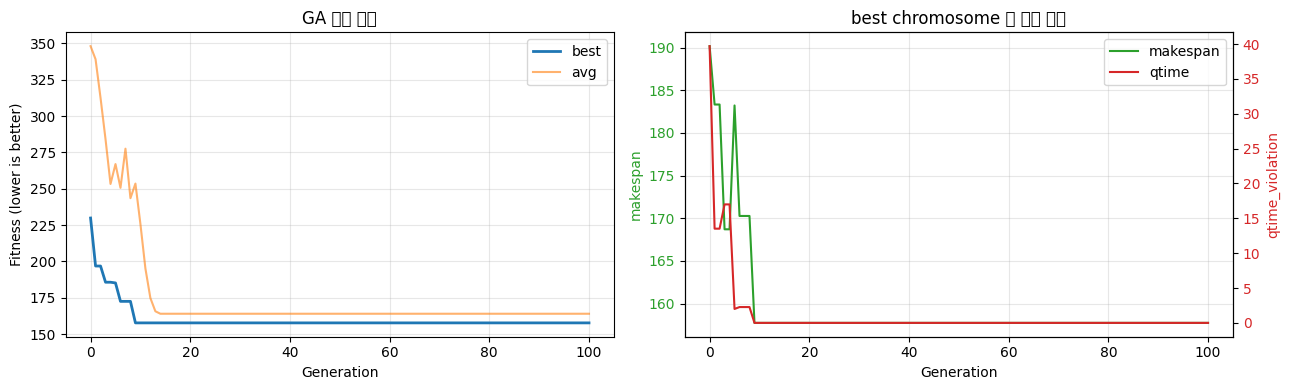

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

df_history = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (1) Fitness 수렴 곡선
axes[0].plot(df_history['gen'], df_history['best_fitness'], label='best', color='C0', linewidth=2)
axes[0].plot(df_history['gen'], df_history['avg_fitness'], label='avg', color='C1', alpha=0.6)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Fitness (lower is better)')
axes[0].set_title('GA 수렴 곡선')
axes[0].legend()
axes[0].grid(alpha=0.3)

# (2) Best chromosome의 두 지표 변화 (makespan, qtime)
ax2 = axes[1]
l1 = ax2.plot(df_history['gen'], df_history['best_makespan'], label='makespan', color='C2')
ax2.set_xlabel('Generation')
ax2.set_ylabel('makespan', color='C2')
ax2.tick_params(axis='y', labelcolor='C2')

ax2_t = ax2.twinx()
l2 = ax2_t.plot(df_history['gen'], df_history['best_qtime'], label='qtime', color='C3')
ax2_t.set_ylabel('qtime_violation', color='C3')
ax2_t.tick_params(axis='y', labelcolor='C3')

ax2.set_title('best chromosome 두 지표 변화')
ax2.grid(alpha=0.3)

# 두 축의 legend 합치기
lines = l1 + l2
ax2.legend(lines, [l.get_label() for l in lines], loc='upper right')

plt.tight_layout()
plt.show()

## 8. 초기 vs 최종 비교

GA가 무작위 시작점(gen 0)에서 얼마나 개선했는지 확인.

In [14]:
init = history[0]
final = history[-1]

print('─── 초기 (gen 0, 무작위 30개) ───')
print(f"  best fitness: {init['best_fitness']:.2f}")
print(f"    makespan:   {init['best_makespan']:.2f}")
print(f"    qtime:      {init['best_qtime']:.2f}")
print(f"  avg  fitness: {init['avg_fitness']:.2f}")
print()
print('─── 최종 (GA 진화 후) ───')
print(f"  best fitness: {final['best_fitness']:.2f}")
print(f"    makespan:   {final['best_makespan']:.2f}")
print(f"    qtime:      {final['best_qtime']:.2f}")
print(f"  avg  fitness: {final['avg_fitness']:.2f}")
print()

improvement = (init['best_fitness'] - final['best_fitness']) / init['best_fitness'] * 100
print(f"best fitness 개선율: {improvement:.1f}%")

─── 초기 (gen 0, 무작위 30개) ───
  best fitness: 229.87
    makespan:   190.17
    qtime:      39.70
  avg  fitness: 348.08

─── 최종 (GA 진화 후) ───
  best fitness: 157.74
    makespan:   157.74
    qtime:      0.00
  avg  fitness: 164.03

best fitness 개선율: 31.4%


## 9. 최종 best chromosome 정보

GA가 찾아낸 최적 해의 디코딩 결과 (시뮬에 실제로 들어간 정보).

In [15]:
sim_input_best = decode(best, encoded)

print('─── best chromosome (정수) ───')
print(f"  job_seq: {best.job_seq}")
print(f"  machine: {best.machine}")
print(f"  pm:      {best.pm}")
print(f"  fitness: makespan={best.fitness[0]:.2f}, qtime={best.fitness[1]:.2f}")
print()
print('─── 디코딩 결과 (시뮬 실제 입력) ───')
print(f"  job 투입 순서: {sim_input_best.job_priority}")
print(f"  pm_thresholds: {sim_input_best.pm_thresholds}")
print()
print('  op별 머신 할당 (앞 10개):')
for op, m in list(sim_input_best.op_machine.items())[:10]:
    print(f"    {op} → {m}")

─── best chromosome (정수) ───
  job_seq: [0, 4, 6, 8, 3, 2, 1, 9, 5, 7]
  machine: [1, 1, 2, 0, 0, 0, 2, 2, 0, 0, 2, 2, 1, 0, 2, 1, 1, 1, 2, 1, 0, 2, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 2]
  pm:      [0, 1, 0, 3, 2, 0, 4, 2]
  fitness: makespan=157.74, qtime=0.00

─── 디코딩 결과 (시뮬 실제 입력) ───
  job 투입 순서: ['J1', 'J5', 'J7', 'J9', 'J4', 'J3', 'J2', 'J10', 'J6', 'J8']
  pm_thresholds: {'M1': 0.05, 'M2': 0.1, 'M3': 0.05, 'M4': 0.5, 'M5': 0.2, 'M6': 0.05, 'M7': 1.0, 'M8': 0.2}

  op별 머신 할당 (앞 10개):
    J1_O1 → M2
    J1_O2 → M5
    J1_O3 → M3
    J1_O4 → M6
    J2_O1 → M1
    J2_O2 → M4
    J2_O3 → M8
    J3_O1 → M3
    J3_O2 → M4
    J3_O3 → M1
